#### **FACTIBILIDAD DE LA SOLUCIÓN**

In [644]:
import pandas as pd 
import matplotlib.pyplot as plt
from importlib import reload

import Clases.asignacion as asignacion_module
reload(asignacion_module)
from Clases.asignacion import Asignacion

import Clases.caja as caja_module
reload(caja_module)
from Clases.caja import Caja

import Clases.producto as producto_module
reload(producto_module)
from Clases.producto import Producto

import Clases.solucion as solucion_module
reload(solucion_module)
from Clases.solucion import Solucion

catalogo_productos = pd.read_csv("Datos-finales/catalogo_productos.csv")
especificaciones_cajas = pd.read_csv("Datos-finales/especificaciones_cajas.csv")
operaciones_planta = pd.read_csv("Datos-finales/operaciones_planta.csv")
procurement_cajas = pd.read_csv("Datos-finales/procurement_cajas.csv")

Guardamos primero los tipos de cajas y productos en listas de python.

In [645]:
caja_compras_merge = especificaciones_cajas.merge(procurement_cajas,
                                                  on="caja_tipo_id")

cajas = [
    Caja(
        caja_id = row["caja_tipo_id"],
        dim_interior_ancho = row["caja_interior_ancho"],
        dim_interior_largo = row["caja_interior_largo"],
        dim_interior_alto = row["caja_interior_alto"]
    )
    for _, row in caja_compras_merge.iterrows()
]

cajas[:5]

[<Caja 02cf77de65b70dd77905e2e33d78478f | Int: 296.0 x 395.0 x 291.0mm | Compra Total: 0>,
 <Caja 082c1cdb42b1abd201403ca33ca11ef0 | Int: 248.0 x 383.0 x 189.0mm | Compra Total: 0>,
 <Caja 0835ff365412a67b720a19713ec250f3 | Int: 286.0 x 386.0 x 278.0mm | Compra Total: 0>,
 <Caja 0b72571a5bb7429ce7de424547e8d27d | Int: 286.0 x 386.0 x 174.0mm | Compra Total: 0>,
 <Caja 10c5f9edbe2c87186bcdeb991fe8d902 | Int: 252.0 x 380.0 x 228.0mm | Compra Total: 0>]

In [646]:
prod_op_merge = catalogo_productos.merge(operaciones_planta, on="codigo_producto")

productos = [
    Producto(
        codigo_producto = row['codigo_producto'],
        cantidad_paquetes = row['cantidad_paquetes'],
        peso_paquete = row['peso_neto_paquete'],
        demanda_buenos_aires = row['volumen_producto_planta_buenos_aires'],
        demanda_curitiba = row['volumen_producto_planta_curitiba'],
        demanda_santiago = row['volumen_producto_planta_santiago'],
        demanda_monterrey = row['volumen_producto_planta_monterrey'],
        demanda_bakersfield = row['volumen_producto_planta_bakersfield'],
        dim_producto_ancho = row['dim_producto_ancho'], 
        dim_producto_largo = row['dim_producto_largo'],
        dim_producto_alto = row['dim_producto_alto']
    )
    for _, row in prod_op_merge.iterrows()
]

productos[:5]

[<Producto BR0001 | Dim Prod: 286.0 x 386.0 x 303.0mm | Demanda Total: 1546613>,
 <Producto BR0002 | Dim Prod: 296.0 x 395.0 x 260.0mm | Demanda Total: 139211>,
 <Producto BR0003 | Dim Prod: 288.0 x 388.0 x 164.0mm | Demanda Total: 172506>,
 <Producto BR0004 | Dim Prod: 296.0 x 395.0 x 224.0mm | Demanda Total: 271715>,
 <Producto BR0005 | Dim Prod: 286.0 x 386.0 x 253.0mm | Demanda Total: 7586>]

#### **Factibilidad con grosor = 5mm**

La idea sería ver cuántos tipos de cajas se pueden asignar por producto, considerando las restricciones de dimensión interna, headspace y resistencia a comprensión. Cada chequeo se verifica dentro de la class Asignacion.

Empecemos viendo la factiblidad con un tamaño de grosor de 5mm

In [647]:
for caja in cajas: 
    caja.elegir_grosor(5)

In [648]:
cajas_asignables_5mm = {}

for producto in productos:
    cajas_asignables = []
    for caja in cajas:
        asignacion = Asignacion(producto, caja)
        if asignacion.es_asignacion_valida():
            cajas_asignables.append(caja)
    
    cajas_asignables_5mm[producto] = cajas_asignables

Veamos en detalle cuántos tipos de cajas son asignables por cada producto.

In [649]:
df_factibilidad_5mm = pd.DataFrame([
    {
        'codigo_producto': producto.codigo_producto,
        'cantidad_cajas_asignables': len(cajas_asign),
    }
    for producto, cajas_asign in cajas_asignables_5mm.items()
])

df_factibilidad_5mm = df_factibilidad_5mm.sort_values('cantidad_cajas_asignables', ascending=False)
df_factibilidad_5mm

,codigo_producto,cantidad_cajas_asignables
243,BR0241,117
144,BR0143,115
309,BR0307,115
283,BR0281,113
126,BR0126,113
...,...,...
43,BR0044,4
45,BR0046,4
46,BR0047,4
44,BR0045,1


Observemos que el espacio de búsqueda se redujo hasta la mitad mínimamente, y como máximo se pueden asignar 117 tipos de cajas a un mismo producto, siendo el caso de BR0241. 

Veamos cómo se distribuye esta cantidad en un gráfico.

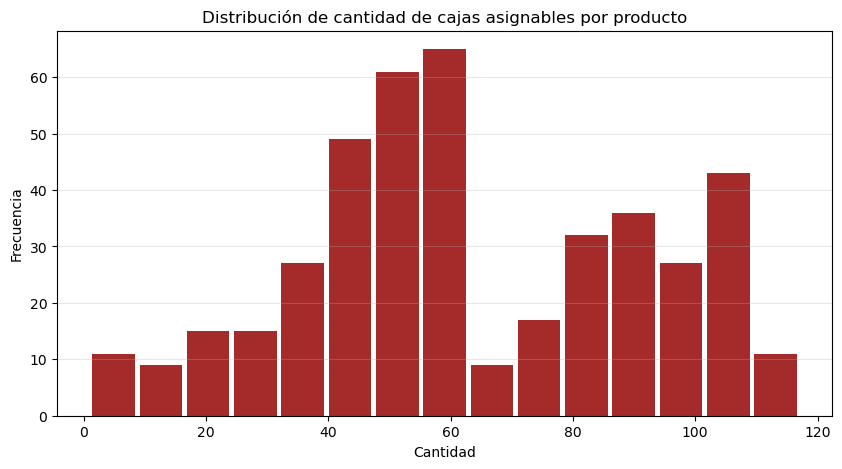

In [650]:
plt.figure(figsize=(10, 5))
plt.hist(df_factibilidad_5mm['cantidad_cajas_asignables'].dropna(), bins=15,
         color='brown', rwidth=0.9)
plt.title('Distribución de cantidad de cajas asignables por producto')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

Podemos notar que la mayoría de productos suelen poder utilizar hasta 60-80 tipos de cajas, aunque hay casos casos que utilizan más de 100. Comparando con la situación original de 204 tipos de cajas, esta reducción nos genera una gran ventaja en la optimización posterior.

Por otro lado, podría llegar a ser interesante ver cuántos productos son asignables por tipo de caja, y en particular ver cuál es el tipo de caja con más posibilidad de ser asignado. 

Además de aumentar los descuentos por los volúmenes altos, esto reduciría significativamente la cantidad de tipos de cajas utilizados.

In [651]:
cajas_conteo_productos = {}
for caja in cajas:
    contador = 0
    for producto in productos:
        asignacion = Asignacion(producto, caja)
        if asignacion.es_asignacion_valida():
            contador += 1
    cajas_conteo_productos[caja.caja_id] = contador

df_productos_por_caja = pd.DataFrame(
    list(cajas_conteo_productos.items()),
    columns=['caja_id', 'cantidad_productos']
)

df_productos_por_caja = df_productos_por_caja.sort_values('cantidad_productos', ascending=False)
df_productos_por_caja

,caja_id,cantidad_productos
118,a130566667d4be7bb38053adaefea0af,234
200,fc6931875b8384c7bacd18bb4699795f,231
138,ae072ed4f441d6f7ab5283589778daca,229
173,d57ede415e9b30ea0e94a15552298aa3,228
101,83d3c7c10fbc6fe2e476fd8c600855e2,227
...,...,...
60,4f15606db1c337e2b9460243b25326d4,11
160,c98f51071fa8c135d7071023f6b23ac0,11
156,c4661c6946240f8ff854e9255c97cbc9,10
196,f201c0669374a768669461ddff1643e4,8


Notemos que la mayoría de tipos de cajas pueden ser asignados a varios productos, siendo el valor máximo un total de 234 productos. La selección óptima explica que comprar más de esos tipos de cajas permitiría que haya un mayor descuento por compra.

Exportemos los resultados a csv:

In [652]:
datos = []

for producto, cajas_asign in cajas_asignables_5mm.items():
    ids_cajas = [caja.caja_id for caja in cajas_asign]  
    datos.append({
        'codigo_producto': producto.codigo_producto,
        'volumen_producto_total': producto.demanda_total(),
        'cajas_asignables_id': '; '.join(ids_cajas)
    })


df_cajas_asignables_5mm = pd.DataFrame(datos)

# Reordenamos los index según el orden de catalogo original
df_cajas_asignables_5mm = catalogo_productos[['codigo_producto']].merge(
    df_cajas_asignables_5mm, 
    on='codigo_producto', 
    how='inner'
)

df_cajas_asignables_5mm.to_csv('Factibilidad/factibilidad_5mm.csv', index=False)

#### **Factibilidad con grosor = 4.5mm**

Repetimos el análisis con un tamaño de grosor de 4.5mm.

In [653]:
for caja in cajas: 
    caja.elegir_grosor(4.5)

In [654]:
cajas_asignables_4p5mm = {}

for producto in productos:
    cajas_asignables = []
    for caja in cajas:
        asignacion = Asignacion(producto, caja)
        if asignacion.es_asignacion_valida():
            cajas_asignables.append(caja)
    
    cajas_asignables_4p5mm[producto] = cajas_asignables

In [655]:
df_factibilidad_4p5mm = pd.DataFrame([
    {
        'codigo_producto': producto.codigo_producto,
        'cantidad_cajas_asignables': len(cajas_asign),
    }
    for producto, cajas_asign in cajas_asignables_4p5mm.items()
])

df_factibilidad_4p5mm = df_factibilidad_4p5mm.sort_values('cantidad_cajas_asignables', ascending=False)
df_factibilidad_4p5mm

,codigo_producto,cantidad_cajas_asignables
144,BR0143,112
243,BR0241,111
126,BR0126,110
309,BR0307,108
307,BR0305,108
...,...,...
42,BR0043,4
227,BR0225,3
226,BR0224,3
44,BR0045,1


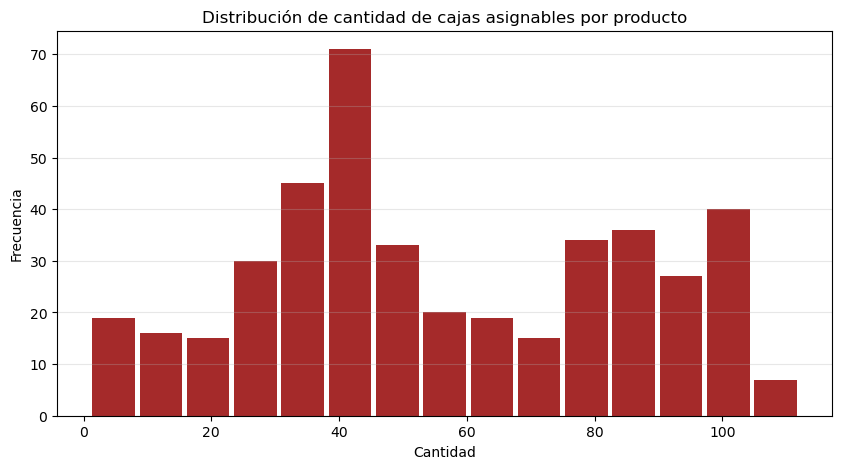

In [656]:
plt.figure(figsize=(10, 5))
plt.hist(df_factibilidad_4p5mm['cantidad_cajas_asignables'].dropna(), bins=15,
         color='brown', rwidth=0.9)
plt.title('Distribución de cantidad de cajas asignables por producto')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [657]:
datos = []

for producto, cajas_asign in cajas_asignables_4p5mm.items():
    ids_cajas = [caja.caja_id for caja in cajas_asign]  
    datos.append({
        'codigo_producto': producto.codigo_producto,
        'volumen_producto_total': producto.demanda_total(),
        'cajas_asignables_id': '; '.join(ids_cajas)
    })


df_cajas_asignables_4p5mm = pd.DataFrame(datos)

# Reordenamos los index según el orden de catalogo original
df_cajas_asignables_4p5mm = catalogo_productos[['codigo_producto']].merge(
    df_cajas_asignables_4p5mm, 
    on='codigo_producto', 
    how='inner'
)

df_cajas_asignables_4p5mm.to_csv('Factibilidad/factibilidad_4.5mm.csv', index=False)

#### **Factibilidad con grosor = 3mm**

Por último, repetimos el análisis con un tamaño de grosor de 3mm.

In [658]:
for caja in cajas: 
    caja.elegir_grosor(3)

In [659]:
cajas_asignables_3mm = {}

for producto in productos:
    cajas_asignables = []
    for caja in cajas:
        asignacion = Asignacion(producto, caja)
        if asignacion.es_asignacion_valida():
            cajas_asignables.append(caja)
    
    cajas_asignables_3mm[producto] = cajas_asignables

In [660]:
df_factibilidad_3mm = pd.DataFrame([
    {
        'codigo_producto': producto.codigo_producto,
        'cantidad_cajas_asignables': len(cajas_asign),
    }
    for producto, cajas_asign in cajas_asignables_3mm.items()
])

df_factibilidad_3mm = df_factibilidad_3mm.sort_values('cantidad_cajas_asignables', ascending=False)
df_factibilidad_3mm

,codigo_producto,cantidad_cajas_asignables
126,BR0126,104
243,BR0241,104
309,BR0307,103
307,BR0305,103
144,BR0143,103
...,...,...
42,BR0043,3
46,BR0047,3
45,BR0046,3
57,BR0058,1


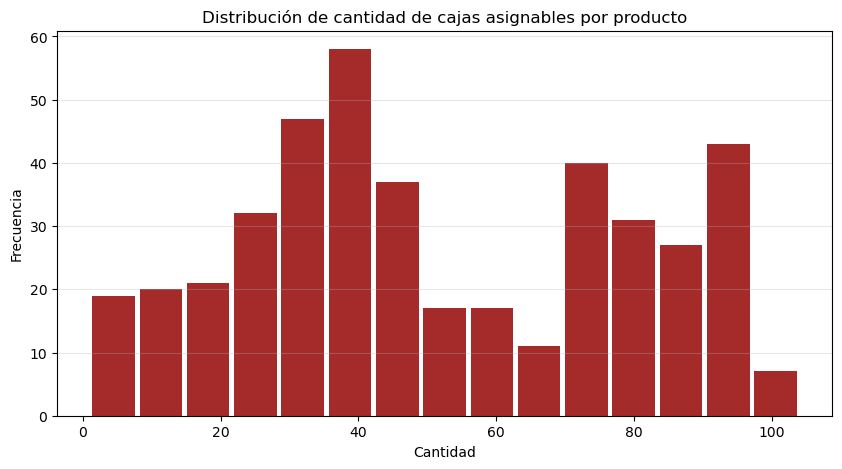

In [661]:
plt.figure(figsize=(10, 5))
plt.hist(df_factibilidad_3mm['cantidad_cajas_asignables'].dropna(), bins=15,
         color='brown', rwidth=0.9)
plt.title('Distribución de cantidad de cajas asignables por producto')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [662]:
datos = []

for producto, cajas_asign in cajas_asignables_3mm.items():
    ids_cajas = [caja.caja_id for caja in cajas_asign]  
    datos.append({
        'codigo_producto': producto.codigo_producto,
        'volumen_producto_total': producto.demanda_total(),
        'cajas_asignables_id': '; '.join(ids_cajas)
    })


df_cajas_asignables_3mm = pd.DataFrame(datos)

# Reordenamos los index según el orden de catalogo original
df_cajas_asignables_3mm = catalogo_productos[['codigo_producto']].merge(
    df_cajas_asignables_3mm, 
    on='codigo_producto', 
    how='inner'
)

df_cajas_asignables_3mm.to_csv('Factibilidad/factibilidad_3mm.csv', index=False)